In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import json
student ={
    "name":"Agamemnon",
    "age":47,
    "department":"CSE",
    "semester":4,
    "subject":["AI","networking","compiler designing"]
    
}
with open("student.json","w")as file:
    json.dump(student,file,indent=4)

In [14]:
#import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

#load the dataset
path="/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"
iris=pd.read_csv(path)

#Display dataset information
print("Shape of the dataset:",iris.shape)
print("\nFirst 5 rows:")
print(iris.head())
#Select Features (X)and Target(Y)
X=iris.iloc[:,1:5]
y=iris["Species"]

#Split the dataset into Training and Testing sets
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
    
)
#Create the KNN model
knn=KNeighborsClassifier(n_neighbors=3)

#Train the model
knn.fit(X_train,y_train)

#Predict on the test data
y_pred=knn.predict(X_test)
print(y_pred)

print("\nActual Species:")
print(y_test.values)

#calaculate accuracy
accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy:",accuracy*100,"%")

#confusion matrix 
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

#classification report
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Shape of the dataset: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-set

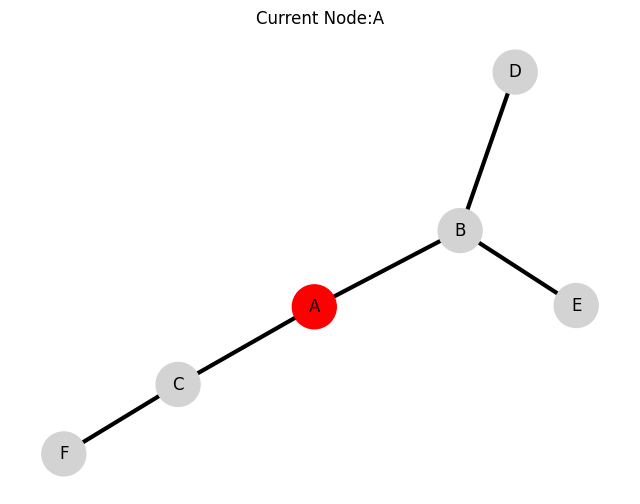

In [34]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation #for animated graph
from collections import deque #This line imports the deque

G=nx.Graph()
edges = [
    ('A','B'),('A','C'),
    ('B','D'),('B','E'),
    ('C','F'),
]
G.add_edges_from(edges)
visited=[]
parent={}
queue=deque(['A'])

while queue :
    node=queue.popleft()
    if node not in visited:
        visited.append(node)
        for neighbour in sorted(G.neighbors(node)):
            if neighbour not in visited and neighbour not in queue:
                parent[neighbour]=node
                queue.append(neighbour)
pos=nx.spring_layout(G,seed=5)

fig,ax=plt.subplots(figsize=(8,6))
def update(frame):
    ax.clear()
    visited_now= visited[:frame+1]
    node_colors=[
        'red' if n in visited_now else 'lightgray'
        for n in G.nodes()
    ]
    edge_colors=[]

    for u,v in G.edges():
        if(v in parent and parent[v]==u and v in visited_now)or(u in parent and parent[u]==v in visited_new):
            edge_colors.append('green')
        else:
            edge_colors.append('black')
    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1000,
        width=3
    )
    ax.set_title(f"Current Node:{visited[frame]}")
ani=FuncAnimation(
    fig,
    update,
    frames=len(visited),
    interval=1200,
    repeat=False
)
from IPython.display import HTML
HTML(ani.to_jshtml())

        